## Setup

In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [118]:
DATA_VERSION = 'data/2025-04-30'
CNN_DTYPE = pd.Int32Dtype()

## Intersections data

In [119]:
intersections = pd.read_csv(
    f'{DATA_VERSION}/street_intersections.csv',
    usecols=['cnn', 'data_as_of', 'st_name', 'st_type', 'the_geom'],
    dtype={'st_name': 'string', 'st_type': 'string', 'cnn': CNN_DTYPE},
    parse_dates=['data_as_of'],
)

In [120]:
intersections.dtypes

cnn                    Int32
st_name       string[python]
st_type       string[python]
the_geom              object
data_as_of    datetime64[ns]
dtype: object

In [121]:
intersections

,cnn,st_name,st_type,the_geom,data_as_of
0,51950000,GILMAN,AVE,POINT (-122.378784033 37.712929869),2025-04-30 03:33:00
1,50713000,25TH,ST,POINT (-122.380095868 37.753279508),2025-04-30 03:33:00
2,51965000,GILMAN,AVE,POINT (-122.375019661 37.710792411),2025-04-30 03:33:00
3,51943000,POLLOCK,ST,POINT (-122.365869925 37.708431923),2025-04-30 03:33:00
4,50807000,POLLOCK,ST,POINT (-122.364820405 37.709598207),2025-04-30 03:33:00
...,...,...,...,...,...
18529,23766000,SAN BRUNO,AVE,POINT (-122.404971862 37.759502499),2025-04-30 03:33:00
18530,25959000,GOLDEN GATE,AVE,POINT (-122.427016757 37.780193031),2025-04-30 03:33:00
18531,21690000,AVALON,AVE,POINT (-122.430965186 37.72692568),2025-04-30 03:33:00
18532,27317000,ANGLO,ALY,POINT (-122.474740669 37.752447862),2025-04-30 03:33:00


In [122]:
# Concatenate st_name and st_type. Note that some st_type values are missing. In that case just use st_name (do not add trailing space).
intersections['st_name'] = intersections['st_name'].str.cat(
    intersections['st_type'].str.replace('^$', '', regex=True),
    sep=' ',
    na_rep='',
)
del intersections['st_type']

In [123]:
intersections

,cnn,st_name,the_geom,data_as_of
0,51950000,GILMAN AVE,POINT (-122.378784033 37.712929869),2025-04-30 03:33:00
1,50713000,25TH ST,POINT (-122.380095868 37.753279508),2025-04-30 03:33:00
2,51965000,GILMAN AVE,POINT (-122.375019661 37.710792411),2025-04-30 03:33:00
3,51943000,POLLOCK ST,POINT (-122.365869925 37.708431923),2025-04-30 03:33:00
4,50807000,POLLOCK ST,POINT (-122.364820405 37.709598207),2025-04-30 03:33:00
...,...,...,...,...
18529,23766000,SAN BRUNO AVE,POINT (-122.404971862 37.759502499),2025-04-30 03:33:00
18530,25959000,GOLDEN GATE AVE,POINT (-122.427016757 37.780193031),2025-04-30 03:33:00
18531,21690000,AVALON AVE,POINT (-122.430965186 37.72692568),2025-04-30 03:33:00
18532,27317000,ANGLO ALY,POINT (-122.474740669 37.752447862),2025-04-30 03:33:00


In [124]:
# Join by cnn. Aggregate st_name_type by concatenating into comma separted string and take any value for the_tom, and data_as_of
# Ensure that st_name is sorted alphabetically before concatenation
intersections = intersections.groupby('cnn').agg(
    st_name_type=('st_name', lambda x: ', '.join(sorted(x))),
    the_geom=('the_geom', 'first'),
    data_as_of=('data_as_of', 'first'),
).reset_index()
intersections

,cnn,st_name_type,the_geom,data_as_of
0,20010000,"GILROY ST, JAMESTOWN AVE",POINT (-122.389437676 37.715557621),2025-04-30 03:33:00
1,20011000,"GIANTS DR, INGERSON AVE",POINT (-122.38813051 37.716298216),2025-04-30 03:33:00
2,20013000,"GILROY ST, IGNACIO AVE",POINT (-122.388977803 37.716086986),2025-04-30 03:33:00
3,20034000,"CLEO RAND AVE, DONAHUE ST",POINT (-122.370352351 37.728568176),2025-04-30 03:33:00
4,20039000,"EARL ST, JERROLD AVE",POINT (-122.372583555 37.729254505),2025-04-30 03:33:00
...,...,...,...,...
9706,54419000,WEST ACCESS,POINT (-122.421729355 37.712136371),2025-04-30 03:33:00
9707,54422000,GATES ST,POINT (-122.414403423 37.733790443),2025-04-30 03:33:00
9708,54423000,TREASURE ISLAND RD,POINT (-122.371387279 37.812108987),2025-04-30 03:33:00
9709,54424000,SIGNAL RD,POINT (-122.365802159 37.809918013),2025-04-30 03:33:00


## Streets data

In [146]:
ADDRESS_TYPE = pd.Int32Dtype()
INT_ENUM_TYPE = pd.Int8Dtype()
streets = pd.read_csv(
    f'{DATA_VERSION}/streets.csv',
    usecols=[
        'cnn',
        'street',
        'st_type',
        'lf_fadd',
        'lf_toadd',
        'rt_fadd',
        'rt_toadd',
        'f_node_cnn',
        't_node_cnn',
        'classcode',
        'accepted',
        'active',
        'oneway',
        'line',
        'data_as_of',
    ],
    dtype={
        'cnn': CNN_DTYPE,
        'lf_fadd': ADDRESS_TYPE,
        'lf_toadd': ADDRESS_TYPE,
        'rt_fadd': ADDRESS_TYPE,
        'rt_toadd': ADDRESS_TYPE,
        'f_node_cnn': CNN_DTYPE,
        't_node_cnn': CNN_DTYPE,
        'classcode': INT_ENUM_TYPE,
    },
    parse_dates=['data_as_of'],
)
streets

,cnn,lf_fadd,lf_toadd,rt_fadd,rt_toadd,street,st_type,f_node_cnn,t_node_cnn,accepted,active,classcode,oneway,line,data_as_of
0,9999000,301,399,300,398,ORTEGA,ST,27098000,27113000,True,True,5,B,"LINESTRING (-122.466600499 37.752803078, -122....",2025-04-30 03:48:00
1,10000202,501,599,0,0,ORTEGA,ST,32870000,32871000,True,True,5,T,"LINESTRING (-122.468335072 37.753243731, -122....",2025-04-30 03:48:00
2,10002000,801,899,800,898,ORTEGA,ST,27308000,27310000,True,True,5,B,"LINESTRING (-122.472007575 37.752569818, -122....",2025-04-30 03:48:00
3,10010000,1501,1599,1500,1598,ORTEGA,ST,27338000,27379000,True,True,5,B,"LINESTRING (-122.479557564 37.752234616, -122....",2025-04-30 03:48:00
4,10019000,2401,2499,2400,2498,ORTEGA,ST,27674000,27677000,True,True,5,B,"LINESTRING (-122.489193569 37.751806869, -122....",2025-04-30 03:48:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17140,14304000,0,0,0,0,UNNAMED,ST,35136000,35137000,False,True,5,B,"LINESTRING (-122.371117962 37.830712109, -122....",2025-04-30 03:48:00
17141,6535000,0,0,0,0,GRIFFITH,ST,51835000,51834000,False,True,0,B,"LINESTRING (-122.373499523 37.734495279, -122....",2025-04-30 03:48:00
17142,6150201,0,0,1876,1932,GENEVA,AVE,21359000,20428000,True,True,3,F,"LINESTRING (-122.423353436 37.709250951, -122....",2025-04-30 03:48:00
17143,6179000,0,0,0,0,GILMAN,AVE,51950000,51953000,False,True,0,B,"LINESTRING (-122.378784033 37.712929869, -122....",2025-04-30 03:48:00


In [147]:
streets.dtypes

cnn                    Int32
lf_fadd                Int32
lf_toadd               Int32
rt_fadd                Int32
rt_toadd               Int32
street                object
st_type               object
f_node_cnn             Int32
t_node_cnn             Int32
accepted                bool
active                  bool
classcode               Int8
oneway                object
line                  object
data_as_of    datetime64[ns]
dtype: object

## Speed limits

In [ ]:
speed_limits = pd.read_csv(
    f'{DATA_VERSION}/speed_limits.csv',
    usecols=['cnn', 'speedlimit', 'schoolzone', 'schoolzone_limit', 'data_as_of'],
    dtype={
        'cnn': CNN_DTYPE,
        'speedlimit': pd.Int16Dtype(),
    },
    parse_dates=['data_as_of'],
)
speed_limits

/var/folders/yb/f9_t70mn0x95vlx6y2jnbpcr0000gn/T/ipykernel_94078/181972844.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  speed_limits = pd.read_csv(


,cnn,speedlimit,schoolzone,schoolzone_limit,data_as_of
0,5903000,0,NaN,0,2016-05-10
1,10270201,35,NaN,0,2016-05-10
2,5127000,0,NaN,0,2016-05-10
3,2323000,0,NaN,0,2016-05-10
4,7534000,25,NaN,0,2016-05-10
...,...,...,...,...,...
15724,6785000,0,NaN,0,2016-05-10
15725,6533000,0,NaN,0,2016-05-10
15726,7191000,0,NaN,0,2016-05-10
15727,5575000,0,NaN,0,2016-05-10


In [149]:
speed_limits.dtypes

cnn                          Int32
speedlimit                   Int16
schoolzone                  object
schoolzone_limit             int64
data_as_of          datetime64[ns]
dtype: object

In [150]:
# Check count by cnn ID
streets['cnn'].value_counts()

cnn
9999000     1
2188000     1
2109000     1
2126000     1
2127000     1
           ..
10693000    1
10712000    1
10724000    1
10727000    1
6785000     1
Name: count, Length: 17145, dtype: Int64

In [151]:
# Join speedlimit onto streets. Only add speedlimit column
streets_v2 = streets.merge(
    speed_limits[['cnn', 'speedlimit']],
    on='cnn',
    how='left',
)
streets_v2

,cnn,lf_fadd,lf_toadd,rt_fadd,rt_toadd,street,st_type,f_node_cnn,t_node_cnn,accepted,active,classcode,oneway,line,data_as_of,speedlimit
0,9999000,301,399,300,398,ORTEGA,ST,27098000,27113000,True,True,5,B,"LINESTRING (-122.466600499 37.752803078, -122....",2025-04-30 03:48:00,0
1,10000202,501,599,0,0,ORTEGA,ST,32870000,32871000,True,True,5,T,"LINESTRING (-122.468335072 37.753243731, -122....",2025-04-30 03:48:00,0
2,10002000,801,899,800,898,ORTEGA,ST,27308000,27310000,True,True,5,B,"LINESTRING (-122.472007575 37.752569818, -122....",2025-04-30 03:48:00,0
3,10010000,1501,1599,1500,1598,ORTEGA,ST,27338000,27379000,True,True,5,B,"LINESTRING (-122.479557564 37.752234616, -122....",2025-04-30 03:48:00,0
4,10019000,2401,2499,2400,2498,ORTEGA,ST,27674000,27677000,True,True,5,B,"LINESTRING (-122.489193569 37.751806869, -122....",2025-04-30 03:48:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17143,14304000,0,0,0,0,UNNAMED,ST,35136000,35137000,False,True,5,B,"LINESTRING (-122.371117962 37.830712109, -122....",2025-04-30 03:48:00,<NA>
17144,6535000,0,0,0,0,GRIFFITH,ST,51835000,51834000,False,True,0,B,"LINESTRING (-122.373499523 37.734495279, -122....",2025-04-30 03:48:00,0
17145,6150201,0,0,1876,1932,GENEVA,AVE,21359000,20428000,True,True,3,F,"LINESTRING (-122.423353436 37.709250951, -122....",2025-04-30 03:48:00,30
17146,6179000,0,0,0,0,GILMAN,AVE,51950000,51953000,False,True,0,B,"LINESTRING (-122.378784033 37.712929869, -122....",2025-04-30 03:48:00,<NA>


In [152]:
# Count streets by unique speed limit values descending
streets_v2['speedlimit'].value_counts()

speedlimit
0     11840
25     1847
20      910
30      543
35      271
99      233
40       44
45       24
15        4
Name: count, dtype: Int64

In [153]:
# Repalce 0 values with 25mph
streets_v2['speedlimit'] = streets_v2['speedlimit'].replace(0, 25)
streets_v2['speedlimit'].value_counts()

speedlimit
25    13687
20      910
30      543
35      271
99      233
40       44
45       24
15        4
Name: count, dtype: Int64

In [156]:
# Search streets by name mariposa
streets_v2[streets_v2['street'].str.contains('mariposa', case=False)]

,cnn,lf_fadd,lf_toadd,rt_fadd,rt_toadd,street,st_type,f_node_cnn,t_node_cnn,accepted,active,classcode,oneway,line,data_as_of,speedlimit
1768,8716002,951,999,950,998,MARIPOSA,ST,52249000,23655000,False,True,4,B,"LINESTRING (-122.393173807 37.764055599, -122....",2025-04-30 03:48:00,25
1769,8719000,1201,1299,1200,1298,MARIPOSA,ST,23676000,23680000,True,True,4,B,"LINESTRING (-122.395682317 37.763906986, -122....",2025-04-30 03:48:00,25
1770,8720000,1301,1399,1300,1398,MARIPOSA,ST,23680000,23682000,True,True,4,B,"LINESTRING (-122.396644515 37.763850619, -122....",2025-04-30 03:48:00,25
1771,8723000,1701,1799,1700,1798,MARIPOSA,ST,23749000,23752000,True,True,4,B,"LINESTRING (-122.40051424 37.763619149, -122.4...",2025-04-30 03:48:00,25
2003,8716001,901,949,900,948,MARIPOSA,ST,52248000,52249000,False,True,4,B,"LINESTRING (-122.392485618 37.764097998, -122....",2025-04-30 03:48:00,25
2004,8724000,1801,1899,1800,1898,MARIPOSA,ST,23752000,23770000,True,True,4,B,"LINESTRING (-122.401478944 37.763561459, -122....",2025-04-30 03:48:00,25
2005,8730000,2401,2499,2400,2498,MARIPOSA,ST,24019000,24021000,True,True,5,B,"LINESTRING (-122.407304847 37.763187802, -122....",2025-04-30 03:48:00,25
2006,8733000,2701,2799,2700,2798,MARIPOSA,ST,24024000,24046000,True,True,5,B,"LINESTRING (-122.410244115 37.763029333, -122....",2025-04-30 03:48:00,25
2007,8734000,2801,2899,2800,2898,MARIPOSA,ST,24046000,24045000,True,True,5,B,"LINESTRING (-122.411206839 37.762972727, -122....",2025-04-30 03:48:00,25
2008,8735000,2901,2999,2900,2998,MARIPOSA,ST,24045000,24052000,True,True,5,B,"LINESTRING (-122.412173289 37.762915894, -122....",2025-04-30 03:48:00,25


In [161]:
# Count segments by unique street, st_type pair, along with average speed, sorted by count. Show top 20 rows
streets_v2.groupby(['street', 'st_type']).agg(
    count=('cnn', 'count'),
    avg_speed=('speedlimit', 'mean'),
).sort_values('count', ascending=False).head(20)

,,count,avg_speed
street,st_type,,
GEARY,BLVD,147,26.319444
03RD,ST,142,24.795082
MISSION,ST,138,21.576923
MARKET,ST,118,24.318182
OCEAN,AVE,112,23.348214
LINCOLN,WAY,99,29.79798
ALEMANY,BLVD,91,31.724138
CALIFORNIA,ST,86,25.0
VAN NESS,AVE,84,25.0


## Injuries

In [227]:
injuries = pd.read_csv(
    f'{DATA_VERSION}/traffic_crashes_resulting_in_injury.csv',
    usecols=[
        'unique_id',
        'cnn_intrsctn_fkey',
        'cnn_sgmt_fkey',
        'tb_latitude',
        'tb_longitude',
        'collision_datetime',
        'weather_1',
        'weather_2',
        'collision_severity',
        'type_of_collision',
        'mviw', # motor vehicle involved with
        'ped_action',
        'road_surface',
        'road_cond_1',
        'road_cond_2',
        'lighting',
        'intersection', # indicates whether the crash occurred in an intersection
        # California vehicle code primary collision factor violated
        'vz_pcf_code',
        # groupings of similar vehicle codes violated
        'vz_pcf_group',
        # description of vehicle code violated,
        'vz_pcf_description',
        # 'vz_pcf_link',
        'number_killed',
        'number_injured',
        'street_view',

        # Generic crash grouping based on parties involved
        'dph_col_grp',
        'dph_col_grp_description',

        # 1 or 2
        'party_at_fault',
        'party1_type',
        'party1_dir_of_travel',
        'party1_move_pre_acc',
        'party2_type',
        'party2_dir_of_travel',
        'party2_move_pre_acc'
    ],
    dtype={
        'cnn_intrsctn_fkey': CNN_DTYPE,
        'cnn_sgmt_fkey': CNN_DTYPE,
        'party_at_fault': pd.Int8Dtype(),
        'number_killed': pd.Int16Dtype(),
        'number_injured': pd.Int16Dtype(),
    },
    parse_dates=['collision_datetime'],
)
injuries

,unique_id,cnn_intrsctn_fkey,cnn_sgmt_fkey,tb_latitude,tb_longitude,collision_datetime,weather_1,weather_2,collision_severity,type_of_collision,...,street_view,dph_col_grp,dph_col_grp_description,party_at_fault,party1_type,party1_dir_of_travel,party1_move_pre_acc,party2_type,party2_dir_of_travel,party2_move_pre_acc
0,77939,23797000,270002,37.775475,-122.392941,2020-01-09 09:13:00,Clear,Not Stated,Injury (Other Visible),Hit Object,...,https://maps.google.com/maps?q=&layer=c&cbll=3...,FF,Bicycle Only,<NA>,Bicyclist,North,Proceeding Straight,NaN,NaN,NaN
1,4768,21791000,11439105,37.731302,-122.435224,2010-09-19 11:39:00,Cloudy,Raining,Injury (Other Visible),Other,...,https://maps.google.com/maps?q=&layer=c&cbll=3...,AA,Vehicle(s) Only Involved,<NA>,Driver,North,Slowing/Stopping,NaN,NaN,NaN
2,54334,21758000,<NA>,37.723601,-122.438809,2020-12-08 18:07:00,Clear,Not Stated,Injury (Complaint of Pain),Other,...,https://maps.google.com/maps?q=&layer=c&cbll=3...,FF,Bicycle Only,<NA>,Bicyclist,North,Proceeding Straight,NaN,NaN,NaN
3,92677,24174000,<NA>,37.763300,-122.421732,2023-11-30 01:58:00,Clear,Not Stated,Injury (Other Visible),Hit Object,...,https://maps.google.com/maps?q=&layer=c&cbll=3...,AA,Vehicle(s) Only Involved,<NA>,Other,Not Stated,Other,NaN,NaN,NaN
4,40768,33561000,8345201,37.766079,-122.464131,2010-01-16 19:37:00,Raining,Not Stated,Injury (Other Visible),Rear End,...,https://maps.google.com/maps?q=&layer=c&cbll=3...,AA,Vehicle(s) Only Involved,1,Driver,West,Proceeding Straight,Driver,West,Stopped In Road
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61895,17660,33027000,9112101,37.769725,-122.419925,2009-03-30 08:36:00,Clear,Not Stated,Injury (Complaint of Pain),Rear End,...,https://maps.google.com/maps?q=&layer=c&cbll=3...,AA,Vehicle(s) Only Involved,1,Driver,North,Proceeding Straight,Driver,North,Stopped In Road
61896,14636,23589000,7831101,37.780193,-122.388913,2010-02-17 16:20:00,Clear,Not Stated,Injury (Complaint of Pain),Broadside,...,https://maps.google.com/maps?q=&layer=c&cbll=3...,AA,Vehicle(s) Only Involved,1,Driver,West,Proceeding Straight,Driver,West,Making Right Turn
61897,27382,24741000,<NA>,37.790565,-122.405574,2010-05-23 19:07:00,Clear,Not Stated,Injury (Other Visible),Sideswipe,...,https://maps.google.com/maps?q=&layer=c&cbll=3...,CC,Vehicle-Bicycle,1,Bicyclist,North,Proceeding Straight,Driver,North,Proceeding Straight
61898,43702,27545000,<NA>,37.776302,-122.484461,2015-09-03 18:11:00,Clear,Not Stated,Injury (Other Visible),Sideswipe,...,https://maps.google.com/maps?q=&layer=c&cbll=3...,AA,Vehicle(s) Only Involved,1,Driver,South,Making Left Turn,Driver,North,Proceeding Straight


In [228]:
injuries.dtypes

unique_id                           int64
cnn_intrsctn_fkey                   Int32
cnn_sgmt_fkey                       Int32
tb_latitude                       float64
tb_longitude                      float64
collision_datetime         datetime64[ns]
weather_1                          object
weather_2                          object
collision_severity                 object
type_of_collision                  object
mviw                               object
ped_action                         object
road_surface                       object
road_cond_1                        object
road_cond_2                        object
lighting                           object
intersection                       object
vz_pcf_code                        object
vz_pcf_group                       object
vz_pcf_description                 object
number_killed                       Int16
number_injured                      Int16
street_view                        object
dph_col_grp                       

In [184]:
# Get total count with non null cnn_intrsctn_fkey, also count for non null cnn_sgmt_fkey
# Display as percentage of total
with_intersection = injuries['cnn_intrsctn_fkey'].notnull().sum() / injuries.shape[0] * 100
with_segment = injuries['cnn_sgmt_fkey'].notnull().sum() / injuries.shape[0] * 100
print(f'With intersection: {with_intersection:.2f}%')
print(f'With segment: {with_segment:.2f}%')

With intersection: 99.97%
With segment: 44.66%


In [239]:
# Show count and distribution of .intersection column enum values
injuries['intersection'].value_counts(dropna=False)

intersection
Intersection <= 20ft              40716
Midblock > 20ft                   16981
Intersection Rear End <= 150ft     4202
NaN                                   1
Name: count, dtype: int64

In [238]:
# Show count and distribution of .weather enum values
injuries['weather_1'].value_counts(dropna=False)


weather_1
Clear                       50990
Cloudy                       6002
Raining                      3674
Not Stated                    674
Fog                           262
Other                         240
Wind                           49
Snowing                         2
Other: Unknown                  1
Other: NOT ON SCENE             1
Fog / Visibility                1
Other: NOT AT SCENE             1
Fog / Visibility: 10 ft         1
Other: MISTING                  1
Fog / Visibility: 800 ft        1
Name: count, dtype: int64

In [237]:
# Show count and distribution of .lighting values
injuries['lighting'].value_counts(dropna=False)

lighting
Daylight                                39865
Dark - Street Lights                    18695
Dusk - Dawn                              2166
Not Stated                                611
Dark - No Street Lights                   454
Dark - Street Lights Not Functioning      109
Name: count, dtype: int64

In [212]:
injuries['collision_severity'].value_counts()

collision_severity
Injury (Complaint of Pain)    39378
Injury (Other Visible)        17585
Injury (Severe)                4349
Fatal                           587
Medical                           1
Name: count, dtype: int64

In [236]:
injuries['type_of_collision'].value_counts(dropna=False)

type_of_collision
Broadside             18967
Vehicle/Pedestrian    12936
Rear End              10036
Sideswipe              8103
Head-On                3722
Other                  3229
Hit Object             2349
Not Stated             1441
Overturned             1117
Name: count, dtype: int64

In [235]:
injuries['mviw'].value_counts(dropna=False)

mviw
Other Motor Vehicle               28428
Pedestrian                        14512
Bicycle                            8422
Fixed Object                       2771
Parked Motor Vehicle               2647
Non-Collision                      1447
Not Stated                         1389
Other Object                       1196
Motor Vehicle on Other Roadway      918
Train                               144
Animal                               26
Name: count, dtype: int64

In [234]:
injuries['ped_action'].value_counts(dropna=False)

ped_action
No Pedestrian Involved                       46176
Crossing in Crosswalk at Intersection         8901
Crossing Not in Crosswalk                     3140
In Road, Including Shoulder                   1915
Not in Road                                    833
Not Stated                                     699
Crossing in Crosswalk Not at Intersection      211
Approaching/Leaving School Bus                  14
Not In Road                                     11
Name: count, dtype: int64

In [233]:
injuries['dph_col_grp_description'].value_counts(dropna=False)

dph_col_grp_description
Vehicle(s) Only Involved                    36512
Vehicle-Pedestrian                          14935
Vehicle-Bicycle                              8325
Bicycle Only                                 1122
Bicycle-Pedestrian                            486
Bicycle-Parked Car                            446
Pedestrian Only or Pedestrian-Parked Car       33
Vehicle-Bicycle-Pedestrian                     18
Unknown/Not Stated                             16
Bicycle-Unknown/Not Stated                      5
NaN                                             2
Name: count, dtype: int64

In [231]:
# Count by type, including null as a category
injuries['party1_type'].value_counts(dropna=False)

party1_type
Driver            50651
Bicyclist          5017
Pedestrian         4852
Other               973
Parked Vehicle      367
Not Stated           27
NaN                  12
Bicycle               1
Name: count, dtype: int64

In [232]:
injuries['party2_type'].value_counts(dropna=False)

party2_type
Driver            38202
Pedestrian        10273
Bicyclist          5447
NaN                4445
Parked Vehicle     2790
Other               724
Not Stated           19
Name: count, dtype: int64

In [245]:
injuries['dph_col_grp_description'].value_counts(dropna=False)

dph_col_grp_description
Vehicle(s) Only Involved                    36512
Vehicle-Pedestrian                          14935
Vehicle-Bicycle                              8325
Bicycle Only                                 1122
Bicycle-Pedestrian                            486
Bicycle-Parked Car                            446
Pedestrian Only or Pedestrian-Parked Car       33
Vehicle-Bicycle-Pedestrian                     18
Unknown/Not Stated                             16
Bicycle-Unknown/Not Stated                      5
NaN                                             2
Name: count, dtype: int64

In [250]:
# Top 20 values
injuries['vz_pcf_description'].value_counts(dropna=False).head(30)

vz_pcf_description
Unsafe speed for prevailing conditions                                                       11564
Red signal - driver or bicyclist responsibilities                                             6334
Driver or bicyclist to yield right-of-way at crosswalks                                       6305
Unknown                                                                                       4452
Unsafe turn or lane change prohibited                                                         4203
Violation of right-of-way - left turn                                                         3796
Following too closely prohibited                                                              2295
Failure to stop at STOP sign                                                                  1972
Unsafe starting or backing on highway                                                         1953
Lane straddling or failure to use specified lanes                                         

In [258]:
# Add "at_fault_party_type" by dereferncing party_at_fault to party1_type or party2_type
injuries['at_fault_party_type'] = pd.NA
injuries.loc[injuries['party_at_fault'] == 1, 'at_fault_party_type'] = injuries['party1_type']
injuries.loc[injuries['party_at_fault'] == 2, 'at_fault_party_type'] = injuries['party2_type']
injuries['at_fault_party_type'].value_counts(dropna=False)

at_fault_party_type
Driver            45641
<NA>               6182
Pedestrian         4617
Bicyclist          4280
Other               822
Parked Vehicle      331
Not Stated           24
NaN                   2
Bicycle               1
Name: count, dtype: int64

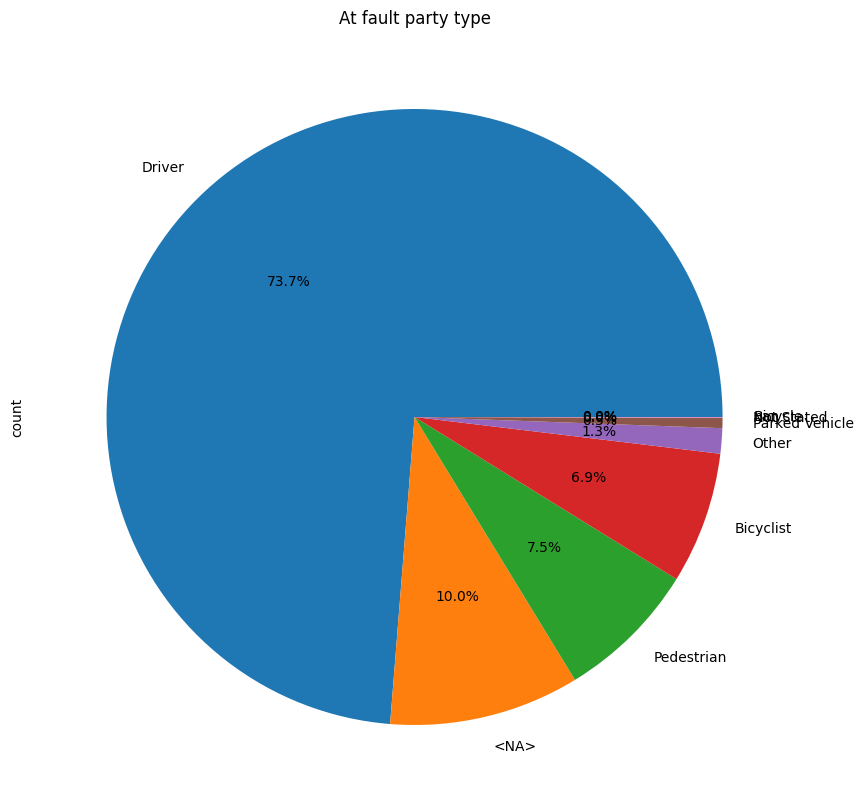

In [259]:
# Display as pie chart
injuries['at_fault_party_type'].value_counts(dropna=False).plot.pie(
    title='At fault party type',
    autopct='%1.1f%%',
    figsize=(10, 10),
)
plt.show()

<Axes: >

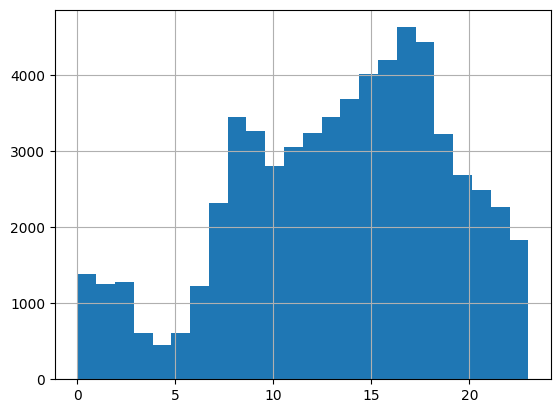

In [207]:
# Plot histgoram of incidents by time of day
injuries['collision_datetime'].dt.hour.hist(bins=24)

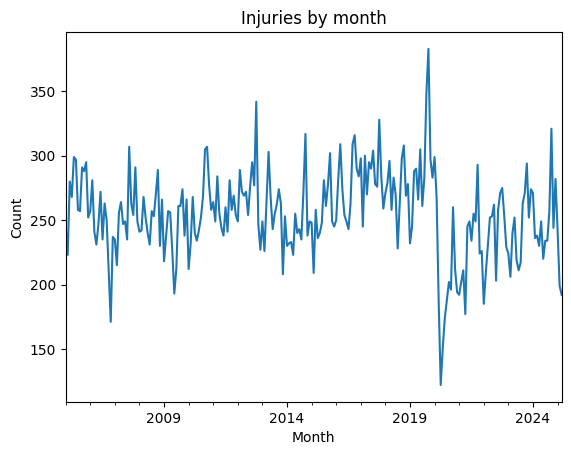

In [185]:
# Matplotlib plot injuries by month. Make sure to not modify the original dataframe. Use line chart
injuries_plot = injuries.copy()
injuries_plot['month'] = injuries_plot['collision_datetime'].dt.to_period('M')
injuries_plot['month'].value_counts().sort_index().plot(
    kind='line',
    title='Injuries by month',
    xlabel='Month',
    ylabel='Count',
)
plt.show()

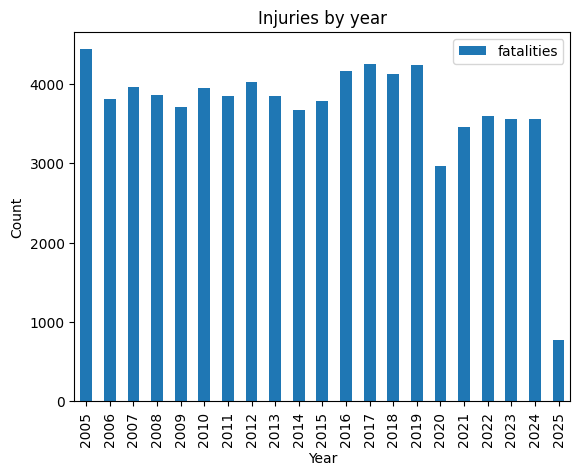

In [211]:
# Plot injuries by year
injuries_plot = injuries.copy()
injuries_plot['year'] = injuries_plot['collision_datetime'].dt.year
injuries_plot.groupby('year').agg(
    fatalities=('number_injured', 'sum'),
).plot(
    kind='bar',
    title='Injuries by year',
    xlabel='Year',
    ylabel='Count',
)
plt.show()

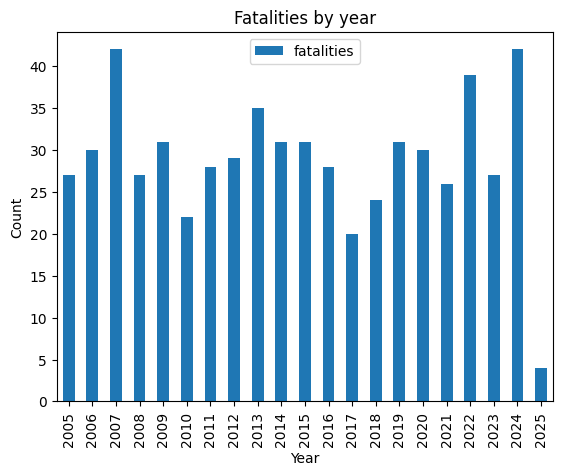

In [ ]:
# Plot fatalaties by year
injuries_plot = injuries.copy()
injuries_plot['year'] = injuries_plot['collision_datetime'].dt.year
injuries_plot.groupby('year').agg(
    fatalities=('number_killed', 'sum'),
).plot(
    kind='bar',
    title='Fatalities by year',
    xlabel='Year',
    ylabel='Count',
)
plt.show()